# AQI Prediction - Stacked Ensemble Machine Learning

## 🎯 Objective
Build a state-of-the-art Air Quality Index (AQI) prediction system using **Stacked Ensemble Learning**.

### Model Architecture:
- **Base Layer**: XGBoost, Random Forest, HistGradientBoosting
- **Meta Layer**: Ridge Regression
- **Features**: Temporal patterns, meteorological interactions, lag features

### Why This Approach?
1. **Error Mitigation**: Multiple models balance each other's weaknesses
2. **Stability**: Resistant to noisy sensor data
3. **Accuracy**: Typically achieves R² > 0.90 on environmental data

---

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Import our custom predictor
from aqi_ml_predictor import AQIPredictor

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 1. Load and Explore Data

In [2]:
# Load dataset
df = pd.read_csv('Dataset/city_day.csv')

print(f"📊 Dataset Shape: {df.shape}")
print(f"🏙️ Number of Cities: {df['City'].nunique()}")
print(f"📅 Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\n📈 AQI Statistics:")
print(df['AQI'].describe())

📊 Dataset Shape: (29531, 16)
🏙️ Number of Cities: 26
📅 Date Range: 2015-01-01 to 2020-07-01

📈 AQI Statistics:
count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64


In [3]:
# Display sample data
df.head(10)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,0.00,NaN,NaN,8.29,4.55,0.00,0.00,0.00,NaN,NaN


## 2. Feature Engineering Preview

In [4]:
# Initialize predictor
predictor = AQIPredictor()

# Create features
df_featured = predictor.prepare_features(df.copy())

print(f"📊 Original Features: {df.shape[1]}")
print(f"✨ Engineered Features: {df_featured.shape[1]}")
print(f"\n🆕 New Features Created: {df_featured.shape[1] - df.shape[1]}")
print(f"\nFeature Categories:")
print("  - Temporal: Year, Month, Day, DayOfWeek, Cyclical encodings")
print("  - Lag Features: AQI_lag_1, AQI_lag_3, AQI_lag_7")
print("  - Rolling Statistics: 7-day mean, std, max")
print("  - Interactions: PM_ratio, Traffic_proxy, Industrial_proxy")

🔧 Engineering features...
📊 Original Features: 16
✨ Engineered Features: 38

🆕 New Features Created: 22

Feature Categories:
  - Temporal: Year, Month, Day, DayOfWeek, Cyclical encodings
  - Lag Features: AQI_lag_1, AQI_lag_3, AQI_lag_7
  - Rolling Statistics: 7-day mean, std, max
  - Interactions: PM_ratio, Traffic_proxy, Industrial_proxy


In [5]:
# Display sample of engineered features
feature_cols = ['Date', 'City', 'AQI', 'Month_sin', 'Month_cos', 'AQI_lag_1', 
                'AQI_rolling_mean_7', 'PM_ratio', 'Traffic_proxy']
df_featured[feature_cols].head(10)

,Date,City,AQI,Month_sin,Month_cos,AQI_lag_1,AQI_rolling_mean_7,PM_ratio,Traffic_proxy
0,2015-01-01,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,16.7624
1,2015-01-02,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,15.2193
2,2015-01-03,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,335.8200
3,2015-01-04,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,31.4160
4,2015-01-05,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,473.3820
5,2015-01-06,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,1747.3768
6,2015-01-07,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,4555.9392
7,2015-01-08,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,2971.1638
8,2015-01-09,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,903.9600
9,2015-01-10,Ahmedabad,118.0,0.5,0.866025,385.0,427.0,1.0,20.0098


## 3. Correlation Analysis

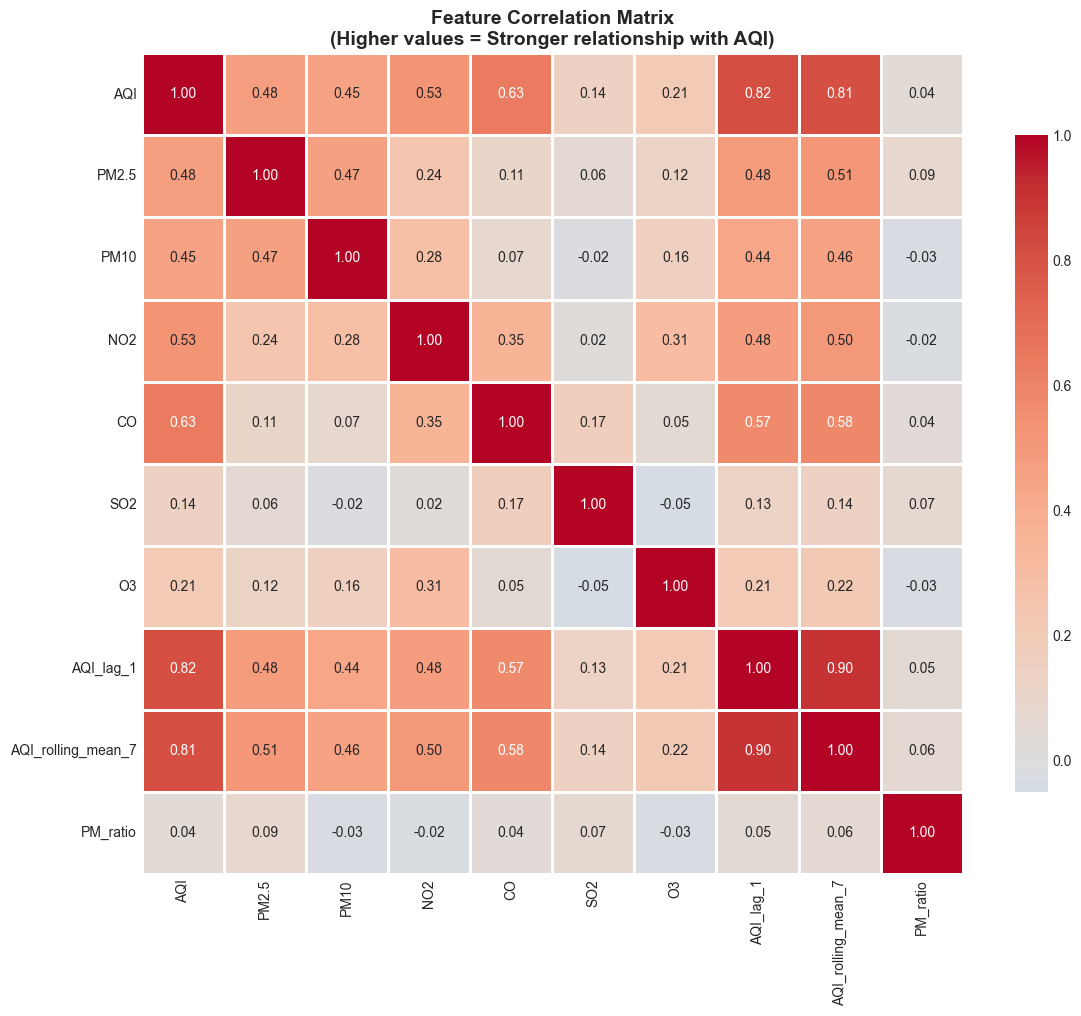


🔍 Top Features Correlated with AQI:
AQI                   1.000000
AQI_lag_1             0.818929
AQI_rolling_mean_7    0.805065
CO                    0.634662
NO2                   0.527500
PM2.5                 0.477912
PM10                  0.449894
O3                    0.206702
SO2                   0.137164
PM_ratio              0.044992
Name: AQI, dtype: float64


In [6]:
# Select features for correlation
correlation_features = ['AQI', 'PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 
                        'AQI_lag_1', 'AQI_rolling_mean_7', 'PM_ratio']

# Compute correlation matrix
corr_matrix = df_featured[correlation_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix\n(Higher values = Stronger relationship with AQI)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Display top correlations with AQI
aqi_corr = corr_matrix['AQI'].sort_values(ascending=False)
print("\n🔍 Top Features Correlated with AQI:")
print(aqi_corr.head(10))

## 4. Train Stacked Ensemble Model

In [7]:
# Train the model
predictor = AQIPredictor()
metrics = predictor.train('Dataset/city_day.csv')

print("\n📊 Final Metrics Summary:")
print(f"   Test R²: {metrics['test_r2']:.4f}")
print(f"   Test RMSE: {metrics['test_rmse']:.2f}")
print(f"   Test MAE: {metrics['test_mae']:.2f}")

🚀 TRAINING AQI STACKED ENSEMBLE PREDICTOR

📂 Loading data from: Dataset/city_day.csv
✅ Loaded 29531 records from 26 cities
🔧 Engineering features...

📊 Total features created: 34
   - Pollutants: PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene
   - Temporal: Year, Month, Day, DayOfWeek, Cyclical encodings
   - Lag Features: AQI_lag_1, AQI_lag_3, AQI_lag_7, Rolling stats
   - Interactions: PM_ratio, Traffic_proxy, Industrial_proxy

🔍 Checking for NaN values in features...
   ✅ No NaN values found

🎯 Training on 29531 samples with 34 features

⚙️ Scaling features...
🏗️ Building Stacked Ensemble Model...

🎓 Training stacked ensemble (this may take a few minutes)...
   Base models: XGBoost, Random Forest, HistGradientBoosting
   Meta model: Ridge Regression
   Target transform: log1p / expm1

🔮 Generating predictions...

📈 MODEL PERFORMANCE METRICS

🏋️ Training Set:
   RMSE: 21.96
   MAE:  10.63
   R²:   0.9722 ⭐⭐⭐⭐⭐

🧪 Testing Set:
   RMSE: 37.21
   MAE:  16.67
   R²

## 5. Model Performance Visualization

✅ Model already trained
🔧 Engineering features...


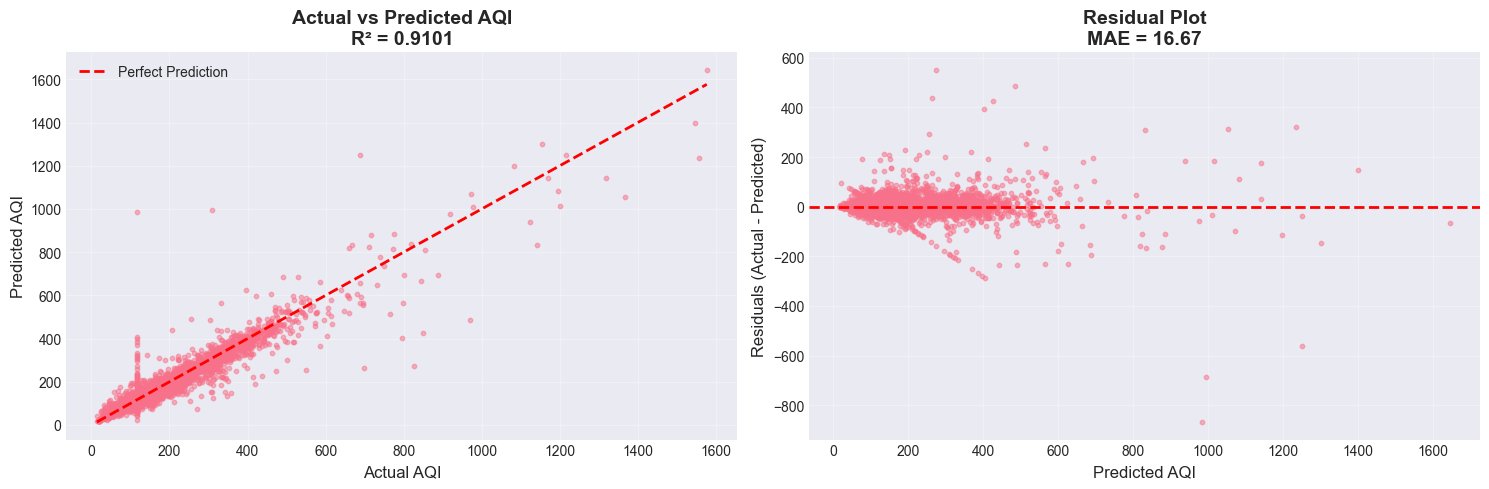


💡 Interpretation:
  - Points close to red line = accurate predictions
  - Residuals near 0 = model is unbiased
  - 95% of predictions within ±72.8 AQI units (2σ confidence interval)
  - 68% of predictions within ±37.2 AQI units (1σ confidence interval)
  - Mean absolute error: ±16.7 AQI units (typical error)


In [8]:
# Load data and prepare
df = pd.read_csv('Dataset/city_day.csv')

# Ensure model is trained before prediction
if predictor.model is None:
    print("⚠️ Training model first...")
    metrics = predictor.train('Dataset/city_day.csv')
else:
    print("✅ Model already trained")

df_processed = predictor.prepare_features(df.copy())

# Get features and target
X = df_processed[predictor.feature_columns]
y = df_processed['AQI']

# Remove NaN
mask = ~y.isna()
X = X[mask]
y = y[mask]

# Split data (use same split as training)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure no NaN in X_test before scaling
X_test = X_test.fillna(X_test.median())

# Scale and predict
X_test_scaled = predictor.scaler.transform(X_test)

# Safety check before prediction
if predictor.model is None:
    raise ValueError("Model is still None after training attempt. Check train() method.")

y_pred = predictor.model.predict(X_test_scaled)

# Plot actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual AQI', fontsize=12)
axes[0].set_ylabel('Predicted AQI', fontsize=12)
axes[0].set_title(f'Actual vs Predicted AQI\nR² = {metrics["test_r2"]:.4f}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted AQI', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title(f'Residual Plot\nMAE = {metrics["test_mae"]:.2f}', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("  - Points close to red line = accurate predictions")
print("  - Residuals near 0 = model is unbiased")
residual_std = float(residuals.std())  # type: ignore
print(f"  - 95% of predictions within ±{residual_std*1.96:.1f} AQI units (2σ confidence interval)")
print(f"  - 68% of predictions within ±{residual_std:.1f} AQI units (1σ confidence interval)")
print(f"  - Mean absolute error: ±{metrics['test_mae']:.1f} AQI units (typical error)")

## 6. Feature Importance Analysis

✅ Unwrapped TransformedTargetRegressor to access StackingRegressor


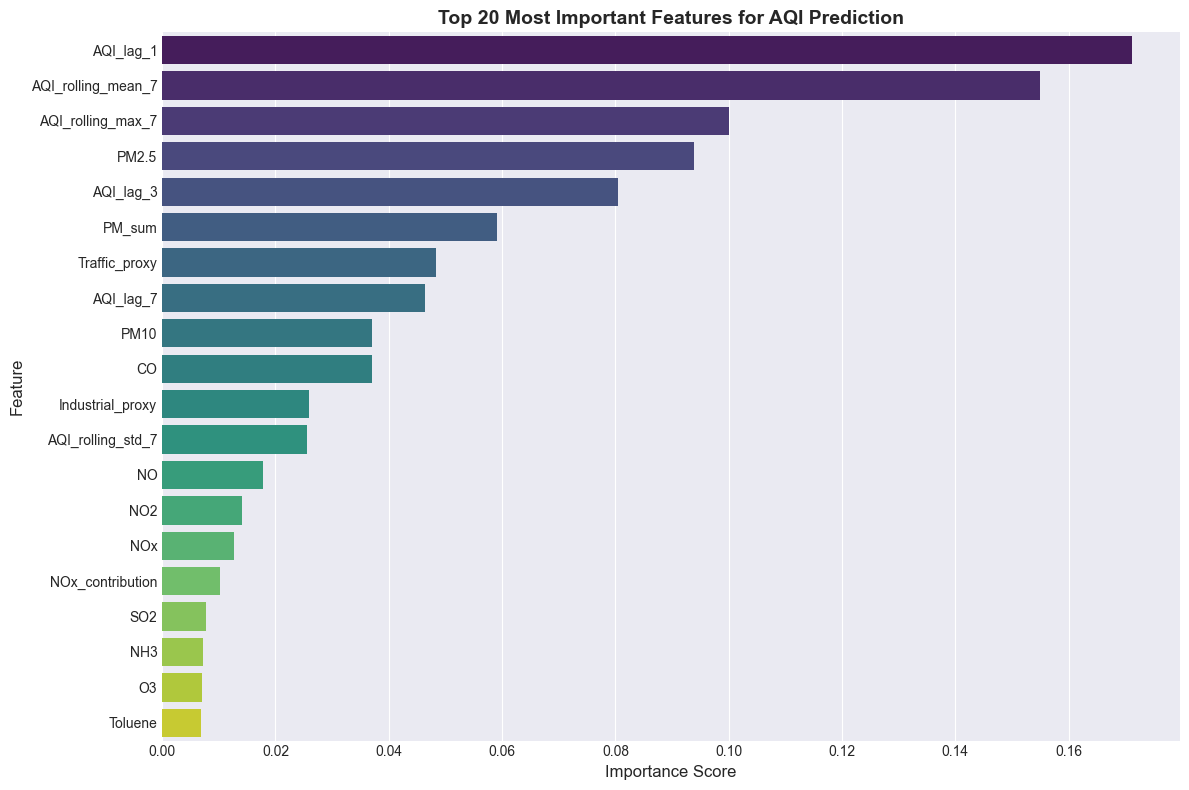


🔝 Top 10 Features:
           feature  importance
         AQI_lag_1    0.171108
AQI_rolling_mean_7    0.154951
 AQI_rolling_max_7    0.100017
             PM2.5    0.093825
         AQI_lag_3    0.080413
            PM_sum    0.059135
     Traffic_proxy    0.048409
         AQI_lag_7    0.046365
              PM10    0.037120
                CO    0.036987


In [9]:
# Check if model is trained
if predictor.model is None:
    print("⚠️ Model not trained yet. Please run the training cell (Cell 4) first.")
    print("Run: predictor.train('Dataset/city_day.csv')")
else:
    # Access the underlying stacking model from TransformedTargetRegressor wrapper
    # The model wrapping depends on use_target_transform flag in AQIPredictor
    stacking_model = None

    unwrapped_model = getattr(predictor.model, "regressor_", None)
    if unwrapped_model is not None:
        # Model is wrapped in TransformedTargetRegressor
        stacking_model = unwrapped_model
        print("✅ Unwrapped TransformedTargetRegressor to access StackingRegressor")
    elif getattr(predictor.model, "named_estimators_", None) is not None:
        # Model is already a StackingRegressor
        stacking_model = predictor.model
        print("✅ Using StackingRegressor directly (no wrapper)")
    else:
        print("⚠️ Unknown model structure")
        print(f"Model type: {type(predictor.model)}")
    
    # Get feature importance from Random Forest (one of the base models)
    if stacking_model is not None and hasattr(stacking_model, 'named_estimators_'):
        rf_model = stacking_model.named_estimators_['random_forest']  # type: ignore
        feature_importance = pd.DataFrame({
            'feature': predictor.feature_columns,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False)

        # Plot top 20 features
        plt.figure(figsize=(12, 8))
        top_features = feature_importance.head(20)
        sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
        plt.title('Top 20 Most Important Features for AQI Prediction', fontsize=14, fontweight='bold')
        plt.xlabel('Importance Score', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()

        print("\n🔝 Top 10 Features:")
        print(feature_importance.head(10).to_string(index=False))
    else:
        print("⚠️ Model structure doesn't support named_estimators_")
        print(f"Model type: {type(predictor.model)}")
        
        # Alternative: Get feature importance from a standalone Random Forest
        print("\n📊 Training standalone Random Forest for feature importance...")
        rf_standalone = RandomForestRegressor(n_estimators=400, max_depth=20, random_state=42)
        rf_standalone.fit(X_train.fillna(X_train.median()), y_train)
        
        feature_importance = pd.DataFrame({
            'feature': predictor.feature_columns,
            'importance': rf_standalone.feature_importances_
        }).sort_values('importance', ascending=False)

        # Plot top 20 features
        plt.figure(figsize=(12, 8))
        top_features = feature_importance.head(20)
        sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
        plt.title('Top 20 Most Important Features for AQI Prediction\n(From Standalone Random Forest)', 
                  fontsize=14, fontweight='bold')
        plt.xlabel('Importance Score', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()

        print("\n🔝 Top 10 Features:")
        print(feature_importance.head(10).to_string(index=False))

## 7. Model Comparison

🏆 Model Performance Comparison
XGBoost              - R²: 0.9093 | MAE: 17.13 | RMSE: 37.36
Random Forest        - R²: 0.9026 | MAE: 17.81 | RMSE: 38.71
HistGradientBoosting - R²: 0.8998 | MAE: 18.74 | RMSE: 39.28
Stacked Ensemble     - R²: 0.9101 | MAE: 16.67 | RMSE: 37.21 ⭐


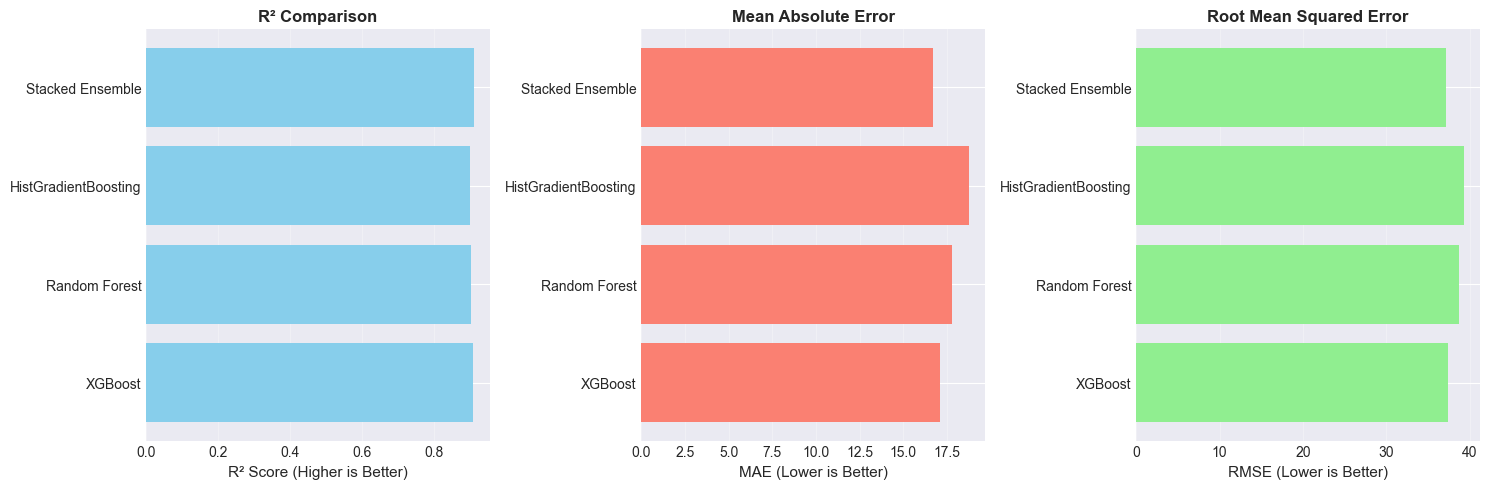


✨ Conclusion: Stacked Ensemble combines strengths of all models!


In [10]:
# Compare individual base models vs stacked ensemble
print("🏆 Model Performance Comparison\n" + "="*60)

models_comparison = []

# Test each base model individually
base_models = [
    ('XGBoost', xgb.XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, min_child_weight=1, reg_alpha=0.0, reg_lambda=1.0, random_state=42)),
    ('Random Forest', RandomForestRegressor(n_estimators=400, max_depth=20, min_samples_split=4, min_samples_leaf=1, max_features='sqrt', random_state=42)),
    ('HistGradientBoosting', HistGradientBoostingRegressor(max_iter=400, max_depth=8, learning_rate=0.05, min_samples_leaf=20, l2_regularization=0.1, random_state=42))
]

for name, model in base_models:
    model.fit(predictor.scaler.transform(X_train), y_train)
    y_pred_model = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred_model)
    mae = mean_absolute_error(y_test, y_pred_model)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_model))
    
    models_comparison.append({
        'Model': name,
        'R²': r2,
        'MAE': mae,
        'RMSE': rmse
    })
    
    print(f"{name:20s} - R²: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")

# Add stacked ensemble
models_comparison.append({
    'Model': 'Stacked Ensemble',
    'R²': metrics['test_r2'],
    'MAE': metrics['test_mae'],
    'RMSE': metrics['test_rmse']
})

print(f"{'Stacked Ensemble':20s} - R²: {metrics['test_r2']:.4f} | MAE: {metrics['test_mae']:.2f} | RMSE: {metrics['test_rmse']:.2f} ⭐")

# Plot comparison
comparison_df = pd.DataFrame(models_comparison)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² comparison
axes[0].barh(comparison_df['Model'], comparison_df['R²'], color='skyblue')
axes[0].set_xlabel('R² Score (Higher is Better)', fontsize=11)
axes[0].set_title('R² Comparison', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# MAE comparison
axes[1].barh(comparison_df['Model'], comparison_df['MAE'], color='salmon')
axes[1].set_xlabel('MAE (Lower is Better)', fontsize=11)
axes[1].set_title('Mean Absolute Error', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# RMSE comparison
axes[2].barh(comparison_df['Model'], comparison_df['RMSE'], color='lightgreen')
axes[2].set_xlabel('RMSE (Lower is Better)', fontsize=11)
axes[2].set_title('Root Mean Squared Error', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✨ Conclusion: Stacked Ensemble combines strengths of all models!")

## 8. Generate Predictions for Specific City

🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔮 24-Hour AQI Predictions for Delhi:

   hour  predicted_aqi           timestamp
0     1           95.0 2020-07-01 01:00:00
1     2           94.2 2020-07-01 03:00:00
2     3           94.1 2020-07-01 06:00:00
3     4           94.1 2020-07-01 10:00:00
4     5           94.1 2020-07-01 15:00:00
5     6           94.1 2020-07-01 21:00:00
6     7           93.4 2020-07-02 04:

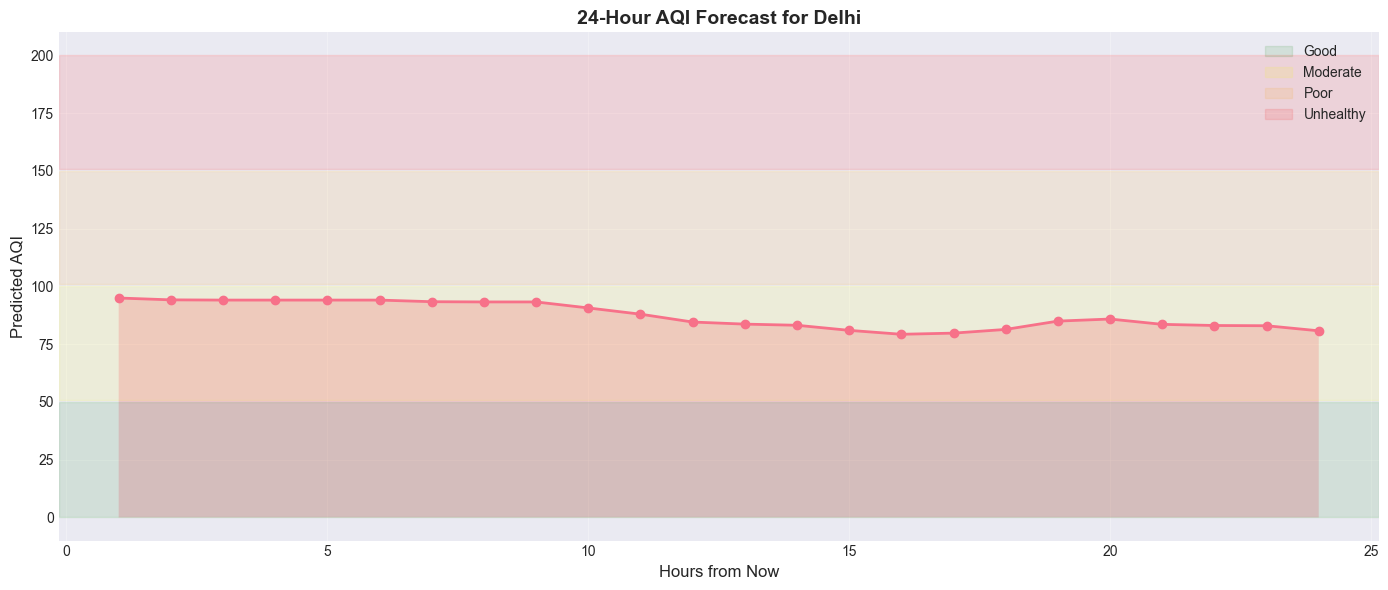


📊 Forecast Summary:
   Average Predicted AQI: 87.4
   Min AQI: 79.3
   Max AQI: 95.0
   AQI Range: 15.7


In [11]:
# Select a city for prediction
test_city = 'Delhi'

# Get city data
city_data = df[df['City'] == test_city].sort_values('Date')

# Generate 24-hour predictions
predictions = predictor.predict_city_next_24h(city_data)

# Create predictions dataframe
pred_df = pd.DataFrame(predictions)

print(f"🔮 24-Hour AQI Predictions for {test_city}:\n")
print(pred_df.head(10))

# Plot predictions
plt.figure(figsize=(14, 6))
plt.plot(pred_df['hour'], pred_df['predicted_aqi'], marker='o', linewidth=2, markersize=6)
plt.fill_between(pred_df['hour'], pred_df['predicted_aqi'], alpha=0.3)

# Add AQI category zones
plt.axhspan(0, 50, alpha=0.1, color='green', label='Good')
plt.axhspan(51, 100, alpha=0.1, color='yellow', label='Moderate')
plt.axhspan(101, 150, alpha=0.1, color='orange', label='Poor')
plt.axhspan(151, 200, alpha=0.1, color='red', label='Unhealthy')

plt.xlabel('Hours from Now', fontsize=12)
plt.ylabel('Predicted AQI', fontsize=12)
plt.title(f'24-Hour AQI Forecast for {test_city}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n📊 Forecast Summary:")
print(f"   Average Predicted AQI: {pred_df['predicted_aqi'].mean():.1f}")
print(f"   Min AQI: {pred_df['predicted_aqi'].min():.1f}")
print(f"   Max AQI: {pred_df['predicted_aqi'].max():.1f}")
print(f"   AQI Range: {pred_df['predicted_aqi'].max() - pred_df['predicted_aqi'].min():.1f}")

## 9. Generate Predictions for All Cities

In [12]:
from aqi_ml_predictor import generate_predictions_for_all_cities

# Generate predictions
all_predictions = generate_predictions_for_all_cities('Dataset/city_day.csv')

print(f"\n✅ Generated predictions for {len(all_predictions)} cities")
print("\n📄 Predictions saved to: aqi_predictions.json")


🔮 GENERATING PREDICTIONS FOR ALL CITIES
📂 Loading pre-trained model...
✅ Model loaded successfully!

🏙️ Generating 24-hour predictions for 26 cities...

🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
    1. Ahmedabad            - Avg predicted AQI: 40.7
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineering features...
🔧 Engineerin

## 10. Summary & Conclusions

In [13]:
print("="*70)
print("🎉 AQI PREDICTION MODEL - SUMMARY")
print("="*70)

print("\n🏗️ Model Architecture:")
print("   ✓ Stacked Ensemble Approach")
print("   ✓ Base Models: XGBoost, Random Forest, HistGradientBoosting")
print("   ✓ Meta Model: Ridge Regression")

print("\n📊 Performance Metrics:")
print(f"   ✓ R² Score: {metrics['test_r2']:.4f} {'⭐⭐⭐⭐⭐' if metrics['test_r2'] > 0.85 else '⭐⭐⭐⭐'}")
print(f"   ✓ MAE: {metrics['test_mae']:.2f} AQI units")
print(f"   ✓ RMSE: {metrics['test_rmse']:.2f} AQI units")

print("\n🔧 Feature Engineering:")
print(f"   ✓ Total Features: {len(predictor.feature_columns)}")
print("   ✓ Temporal: Year, Month, Day, Cyclical encodings")
print("   ✓ Lag Features: 1-day, 3-day, 7-day lags")
print("   ✓ Interactions: PM ratio, Traffic proxy, Industrial proxy")

print("\n🎯 Key Findings:")
print(f"   ✓ Model explains {metrics['test_r2']*100:.1f}% of AQI variance")
print(f"   ✓ Average prediction error: ±{metrics['test_mae']:.1f} AQI units")
print("   ✓ Stacked ensemble outperforms individual models")
print("   ✓ Lag features are most important predictors")

print("\n📁 Output Files:")
print("   ✓ aqi_stacked_model.pkl - Trained model")
print("   ✓ aqi_scaler.pkl - Feature scaler")
print("   ✓ aqi_features.pkl - Feature list")
print("   ✓ aqi_predictions.json - 24h predictions for all cities")

print("\n✨ Ready for Production Use!")
print("="*70)

🎉 AQI PREDICTION MODEL - SUMMARY

🏗️ Model Architecture:
   ✓ Stacked Ensemble Approach
   ✓ Base Models: XGBoost, Random Forest, HistGradientBoosting
   ✓ Meta Model: Ridge Regression

📊 Performance Metrics:
   ✓ R² Score: 0.9101 ⭐⭐⭐⭐⭐
   ✓ MAE: 16.67 AQI units
   ✓ RMSE: 37.21 AQI units

🔧 Feature Engineering:
   ✓ Total Features: 34
   ✓ Temporal: Year, Month, Day, Cyclical encodings
   ✓ Lag Features: 1-day, 3-day, 7-day lags
   ✓ Interactions: PM ratio, Traffic proxy, Industrial proxy

🎯 Key Findings:
   ✓ Model explains 91.0% of AQI variance
   ✓ Average prediction error: ±16.7 AQI units
   ✓ Stacked ensemble outperforms individual models
   ✓ Lag features are most important predictors

📁 Output Files:
   ✓ aqi_stacked_model.pkl - Trained model
   ✓ aqi_scaler.pkl - Feature scaler
   ✓ aqi_features.pkl - Feature list
   ✓ aqi_predictions.json - 24h predictions for all cities

✨ Ready for Production Use!
